In [2]:
from data_analysis import get_algorithm_labels
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_speedup_from_locations(baseline_locations, cache_locations, metric='time', log_scale=True, algorithm_labels=None, save_location=None):
    """
    Plots a logarithmic inverted ECDF comparing multiple caching strategies.
    Supports latency and throughput-normalized speedups.
    Valid 'metric' options: 'time', 'first_ts', 'last_ts', 'throughput'

    Parameters:
    - baseline_locations: List of file paths to baseline data.
    - cache_locations: List of file paths to cache evaluation data.
    - metric: The evaluation metric to calculate speedup against.
    - log_scale: Boolean to apply logarithmic scaling to the Y-axis.
    - algorithm_labels: Optional list of strings matching the length of cache_locations for legend labeling.
    - save_location: Optional file path string to save the resulting PDF/PNG.
    """

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])

                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc) for loc in baseline_locations]
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median',
        'first_ts': 'median',
        'last_ts': 'median',
        'num_results': 'median',
        'throughput': 'median'
    }).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Process Each Cache Strategy
    for i, cache_loc in enumerate(cache_locations):
        # Resolve strategy label
        if algorithm_labels and i < len(algorithm_labels):
            strategy_label = algorithm_labels[i]
        else:
            strategy_label = os.path.basename(cache_loc).replace('.json', '')

        df_cache = parse_file(cache_loc)
        df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
            'time': 'median',
            'first_ts': 'median',
            'last_ts': 'median',
            'num_results': 'median',
            'throughput': 'median'
        }).reset_index()

        merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))

        safe_base_results = np.maximum(1, merged['num_results_base'])
        safe_cache_results = np.maximum(1, merged['num_results_cache'])

        # 3. Calculate Speedup
        if metric == 'first_ts':
            valid_mask = (merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)
            merged = merged[valid_mask].copy()
            merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

        elif metric == 'throughput':
            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Keep queries where at least one succeeded
            valid_mask = (tb > 0) | (tc > 0)
            merged = merged[valid_mask].copy()

            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Identify the three categories
            both_succeeded = (tb > 0) & (tc > 0)
            rescued_by_cache = (tb == 0) & (tc > 0)
            broken_by_cache = (tb > 0) & (tc == 0)

            # Calculate normal speedups to find natural bounds
            normal_speedups = tc[both_succeeded] / tb[both_succeeded]

            max_normal = normal_speedups.max() if not normal_speedups.empty else 10.0
            min_normal = normal_speedups.min() if not normal_speedups.empty else 0.1

            # Create distinct ledges (1 order of magnitude beyond max/min)
            infinity_proxy = max_normal * 10.0
            zero_proxy = min_normal / 10.0

            # Assign speedups categorically
            speedup_col = pd.Series(index=merged.index, dtype=float)
            speedup_col[both_succeeded] = normal_speedups
            speedup_col[rescued_by_cache] = infinity_proxy
            speedup_col[broken_by_cache] = zero_proxy

            merged['speedup'] = speedup_col

        elif metric in ['time', 'last_ts']:
            latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
            result_ratio = safe_cache_results / safe_base_results
            merged['speedup'] = latency_ratio * result_ratio

        else:
            raise ValueError("Invalid metric. Choose 'time', 'first_ts', 'last_ts', or 'throughput'.")

        speedups = merged['speedup'].dropna().values
        speedups = speedups[speedups > 0]
        speedups.sort()

        if len(speedups) > 0:
            percentiles = np.linspace(0, 100, len(speedups))
            ax.step(percentiles, speedups, where='post', linewidth=2, label=strategy_label)

    # 4. Apply Graph Formatting
    ax.axhline(1.0, color='gray', linestyle='-', linewidth=1.5, zorder=1)

    if log_scale:
        ax.set_yscale('log')
        ymin, ymax = ax.get_ylim()

        if ymin > 0 and ymax > 0:
            max_log_dev = max(abs(np.log10(ymin)), abs(np.log10(ymax)))
            ax.set_ylim(10 ** (-max_log_dev), 10 ** max_log_dev)

    metric_labels = {
        'time': 'Total Execution Time',
        'first_ts': 'First Result Arrival Time',
        'last_ts': 'Last Result Arrival Time',
        'throughput': 'Throughput'
    }
    display_metric = metric_labels.get(metric, metric)

    ax.set_xlabel('Query Percentile')
    ax.set_ylabel('Speedup Factor (Baseline / Cached)')
    ax.set_title(f'Caching Speedup Quantile Plot: {display_metric}')

    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(title="Caching Strategy")

    plt.tight_layout()

    # 5. Save and Display
    if save_location:
        output_dir = os.path.dirname(save_location)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_location}")

    plt.show()


import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_faceted_speedup(
    baseline_locations,
    cache_locations_1,
    cache_locations_2,
    cache_locations_3,
    metric='time',
    log_scale=True,
    algorithm_labels_1=None,
    algorithm_labels_2=None,
    algorithm_labels_3=None,
    layout='vertical',
    save_location=None
):
    """
    Plots a faceted, logarithmic inverted ECDF with a split x-axis comparing caching strategies.
    Applies strict academic styling via Seaborn.
    """

    # Apply Target Styling
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    colors = sns.color_palette("colorblind", n_colors=10) # Accommodates up to 10 unique algorithms

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])
                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base = pd.concat([parse_file(loc) for loc in baseline_locations], ignore_index=True)
    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
        'num_results': 'median', 'throughput': 'median'
    }).reset_index()

    # 2. Define Speedup Calculation
    def extract_curves(cache_locations, labels):
        curves = []
        for i, cache_loc in enumerate(cache_locations):
            label = labels[i] if labels and i < len(labels) else os.path.basename(cache_loc).replace('.json', '')
            df_cache = parse_file(cache_loc)
            df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
                'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
                'num_results': 'median', 'throughput': 'median'
            }).reset_index()

            merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))
            safe_base_results = np.maximum(1, merged['num_results_base'])
            safe_cache_results = np.maximum(1, merged['num_results_cache'])

            if metric == 'first_ts':
                merged = merged[(merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)].copy()
                merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

            elif metric == 'throughput':
                tb, tc = merged['throughput_base'], merged['throughput_cache']
                merged = merged[(tb > 0) | (tc > 0)].copy()
                tb, tc = merged['throughput_base'], merged['throughput_cache']

                both_succeeded = (tb > 0) & (tc > 0)
                normal_speedups = tc[both_succeeded] / tb[both_succeeded]

                max_norm = normal_speedups.max() if not normal_speedups.empty else 10.0
                min_norm = normal_speedups.min() if not normal_speedups.empty else 0.1

                speedup_col = pd.Series(index=merged.index, dtype=float)
                speedup_col[both_succeeded] = normal_speedups
                speedup_col[(tb == 0) & (tc > 0)] = max_norm * 10.0
                speedup_col[(tb > 0) & (tc == 0)] = min_norm / 10.0
                merged['speedup'] = speedup_col

            elif metric in ['time', 'last_ts']:
                latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
                merged['speedup'] = latency_ratio * (safe_cache_results / safe_base_results)
            else:
                raise ValueError("Invalid metric.")

            speedups = merged['speedup'].dropna().values
            speedups = speedups[speedups > 0]
            speedups.sort()

            if len(speedups) > 0:
                percentiles = np.linspace(0, 100, len(speedups))
                curves.append((label, percentiles, speedups))
        return curves

    # 3. Process Data Groups
    data_groups = [
        extract_curves(cache_locations_1, algorithm_labels_1),
        extract_curves(cache_locations_2, algorithm_labels_2),
        extract_curves(cache_locations_3, algorithm_labels_3)
    ]

    # 4. Determine Dynamic X-Axis Split Bounds (5% Threshold) & Global Y Limits
    p1, p2 = 0.0, 100.0
    global_min, global_max = 1.0, 1.0

    for group in data_groups:
        for _, p, s in group:
            if len(s) == 0: continue
            global_min = min(global_min, s.min())
            global_max = max(global_max, s.max())

            regs, imps = p[s <= 0.95], p[s >= 1.05]
            if len(regs) > 0: p1 = max(p1, regs.max())
            if len(imps) > 0: p2 = min(p2, imps.min())

    p1 = min(p1 + 1, 45)
    p2 = max(p2 - 1, 55)

    if log_scale and global_min > 0 and global_max > 0:
        max_log_dev = max(abs(np.log10(global_min)), abs(np.log10(global_max)))
        y_lims = (10 ** (-max_log_dev), 10 ** max_log_dev)
    else:
        y_lims = (global_min, global_max)

    # 5. Initialize Grid Based on Layout Parameter
    if layout == 'vertical':
        fig = plt.figure(figsize=(10, 12))
        gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], wspace=0.08, hspace=0.35)
        ax_pairs = [
            (fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])),
            (fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])),
            (fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]))
        ]
    elif layout == 'horizontal':
        fig = plt.figure(figsize=(22, 5))
        gs = fig.add_gridspec(1, 8, width_ratios=[1, 1, 0.3, 1, 1, 0.3, 1, 1], wspace=0.08)
        ax_pairs = [
            (fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])),
            (fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[0, 4])),
            (fig.add_subplot(gs[0, 6]), fig.add_subplot(gs[0, 7]))
        ]
    else:
        raise ValueError("Invalid layout. Choose 'vertical' or 'horizontal'.")

    # 6. Plot Data and Format Split Axes
    global_color_idx = 0
    legend_handles = {}

    for row_idx, (group, (ax_left, ax_right)) in enumerate(zip(data_groups, ax_pairs)):
        for label, percentiles, speedups in group:

            # Map algorithm to a consistent color
            if label not in legend_handles:
                current_color = colors[global_color_idx % len(colors)]
                global_color_idx += 1
            else:
                current_color = legend_handles[label].get_color()

            line, = ax_left.step(percentiles, speedups, where='post', linewidth=1.5, color=current_color, label=label)
            ax_right.step(percentiles, speedups, where='post', linewidth=1.5, color=current_color, label=label)

            if label not in legend_handles:
                legend_handles[label] = line

        # Apply Axis Limits and Grid Formatting
        ax_left.set_xlim(0, p1)
        ax_right.set_xlim(p2, 100)

        for ax in (ax_left, ax_right):
            ax.set_ylim(y_lims)
            # Use styling provided in prompt for baseline
            ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

            if log_scale:
                ax.set_yscale('log')
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

        # Clean Axis Break Styling
        ax_left.spines['right'].set_visible(False)
        ax_right.spines['left'].set_visible(False)

        ax_right.yaxis.tick_right()
        ax_right.tick_params(labelright=False)
        ax_right.tick_params(left=False)

        # Draw diagonal cut marks
        d = 0.015
        kwargs = dict(transform=ax_left.transAxes, color='black', clip_on=False, linewidth=1.5)
        ax_left.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

        kwargs.update(transform=ax_right.transAxes)
        ax_right.plot((-d, +d), (-d, +d), **kwargs)
        ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)

        # Label Management
        if layout == 'vertical':
            if row_idx == 2:
                ax_left.set_xlabel('Pct. (Regressions)')
                ax_right.set_xlabel('Pct. (Improvements)')
            if row_idx == 1:
                ax_left.set_ylabel('Geometric Mean Speedup (vs No Cache)')
        elif layout == 'horizontal':
            ax_left.set_xlabel('Pct. (Regressions)')
            ax_right.set_xlabel('Pct. (Improvements)')
            if row_idx == 0:
                ax_left.set_ylabel('Geometric Mean Speedup (vs No Cache)')
            else:
                ax_left.tick_params(labelleft=False)

    # 7. Global Legend Construction
    fig.legend(
        handles=list(legend_handles.values()),
        labels=list(legend_handles.keys()),
        loc='lower center',
        bbox_to_anchor=(0.5, 1.05 if layout == 'horizontal' else 1.02),
        ncol=min(len(legend_handles), 5),
        frameon=True,
        edgecolor='black',
        fontsize=11
    )

    # 8. Save and Display
    if save_location:
        os.makedirs(os.path.dirname(save_location), exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight', facecolor='white')

    plt.show()

if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_locations_cache = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l ]
    all_locations_cache_no_estimation = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                                          raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache = [ raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_s,
                                           raw_data_query_cache_estimate_m,
                                           raw_data_query_cache_estimate_l ]
    all_locations = [raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                           raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
                           raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l]
    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    # Example calls testing the new throughput metric alongside time
    # plot_speedup_from_locations(location_default, all_locations_cache,
    #                             log_scale=True, metric="time",
    #                             algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_cache_no_estimation,
    #                         log_scale=True, metric="time",
    #                         algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_cache_no_estimation,
    #                         log_scale=True, metric="throughput",
    #                         algorithm_labels=get_algorithm_labels(all_locations_cache))
    #
    # plot_speedup_from_locations(location_default, all_locations_cache,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_query_cache,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_query_cache))
    # plot_speedup_from_locations(location_default, all_locations_query_cache_estimate,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_query_cache_estimate))
    # plot_speedup_from_locations(location_default, all_locations,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations))
    #TODO: Remove 5% thing. Add all plots into single facet to share legend. Add ticker marks to line, move y-axis tickets to the left
    # Change name axis to percentile and make it shared, don't do different axis names
    # Add mapping to algorithm names from file names.

    plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache, all_locations_query_cache_estimate, layout="horizontal", save_location="../output/execution_time_figures/faceted_speedup_total_exec_time.pdf")
    plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache,
                         all_locations_query_cache_estimate, layout="horizontal", metric="throughput",
                         save_location="../output/execution_time_figures/faceted_speedup_total_through_put.pdf")


TypeError: plot_faceted_speedup() got an unexpected keyword argument 'layout'

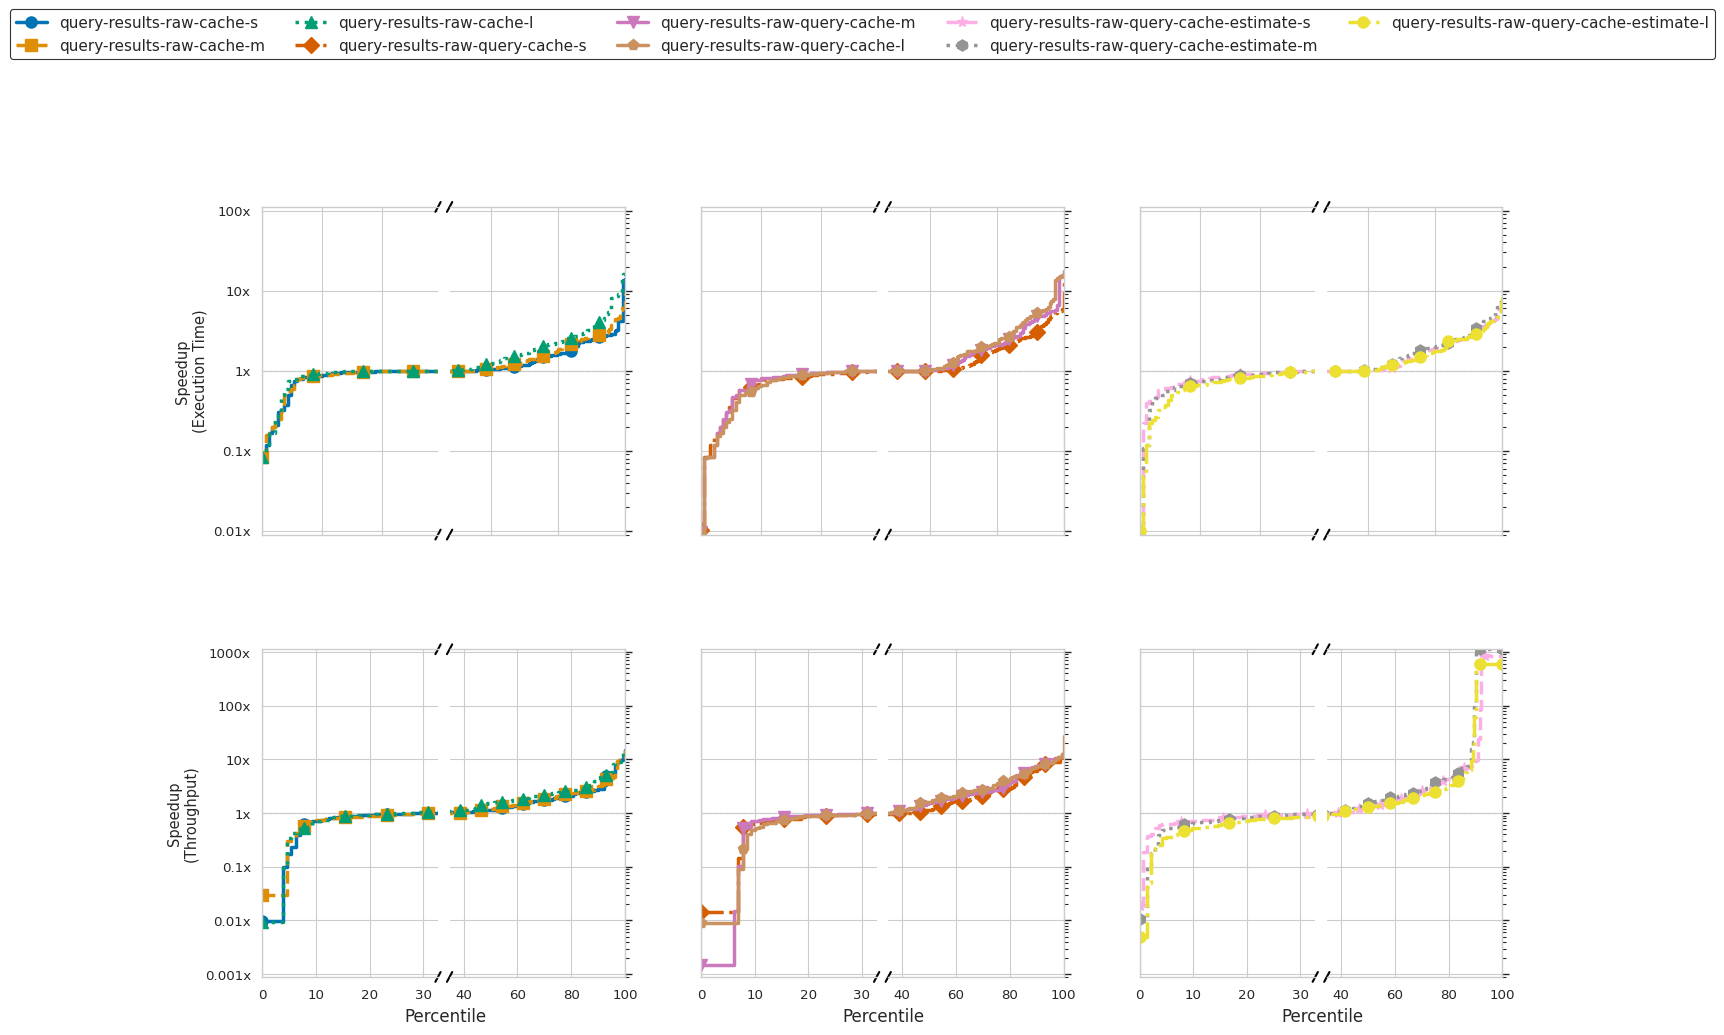

In [13]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

def plot_faceted_speedup(
    baseline_locations,
    cache_locations_1,
    cache_locations_2,
    cache_locations_3,
    metrics=['time'],
    log_scale=True,
    algorithm_labels_1=None,
    algorithm_labels_2=None,
    algorithm_labels_3=None,
    min_speedup_diff=0.0,
    save_location=None
):
    """
    Plots a 2D faceted, logarithmic inverted ECDF with a split x-axis comparing caching strategies.
    Rows represent distinct metrics, and columns represent distinct cache location groups.
    """

    if isinstance(metrics, str):
        metrics = [metrics]

    # Apply Target Styling
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    colors = sns.color_palette("colorblind", n_colors=10)

    # Define robust, colorblind-friendly markers and line styles
    style_markers = ["o", "s", "^", "D", "v", "p", "*", "h"]
    style_lines = ["-", "--", ":", "-.", "-"] * 2

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])
                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base = pd.concat([parse_file(loc) for loc in baseline_locations], ignore_index=True)
    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
        'num_results': 'median', 'throughput': 'median'
    }).reset_index()

    # 2. Define Speedup Calculation
    def extract_curves(cache_locations, labels, current_metric):
        curves = []
        if not cache_locations:
            return curves

        for i, cache_loc in enumerate(cache_locations):
            label = labels[i] if labels and i < len(labels) else os.path.basename(cache_loc).replace('.json', '')
            df_cache = parse_file(cache_loc)
            df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
                'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
                'num_results': 'median', 'throughput': 'median'
            }).reset_index()

            merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))
            safe_base_results = np.maximum(1, merged['num_results_base'])
            safe_cache_results = np.maximum(1, merged['num_results_cache'])

            if current_metric == 'first_ts':
                merged = merged[(merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)].copy()
                merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

            elif current_metric == 'throughput':
                tb, tc = merged['throughput_base'], merged['throughput_cache']
                merged = merged[(tb > 0) | (tc > 0)].copy()
                tb, tc = merged['throughput_base'], merged['throughput_cache']

                both_succeeded = (tb > 0) & (tc > 0)
                normal_speedups = tc[both_succeeded] / tb[both_succeeded]

                max_norm = normal_speedups.max() if not normal_speedups.empty else 10.0
                min_norm = normal_speedups.min() if not normal_speedups.empty else 0.1

                speedup_col = pd.Series(index=merged.index, dtype=float)
                speedup_col[both_succeeded] = normal_speedups
                speedup_col[(tb == 0) & (tc > 0)] = max_norm * 10.0
                speedup_col[(tb > 0) & (tc == 0)] = min_norm / 10.0
                merged['speedup'] = speedup_col

            elif current_metric in ['time', 'last_ts']:
                latency_ratio = merged[f'{current_metric}_base'] / merged[f'{current_metric}_cache']
                merged['speedup'] = latency_ratio * (safe_cache_results / safe_base_results)
            else:
                raise ValueError("Invalid metric.")

            speedups = merged['speedup'].dropna().values
            speedups = speedups[speedups > 0]
            speedups.sort()

            if len(speedups) > 0:
                percentiles = np.linspace(0, 100, len(speedups))
                curves.append((label, percentiles, speedups))
        return curves

    # 3. Process Data per Metric and Calculate Bounds
    num_metrics = len(metrics)
    all_row_data = []

    lower_bound = 1.0 - min_speedup_diff
    upper_bound = 1.0 + min_speedup_diff

    for current_metric in metrics:
        data_groups = [
            extract_curves(cache_locations_1, algorithm_labels_1, current_metric),
            extract_curves(cache_locations_2, algorithm_labels_2, current_metric),
            extract_curves(cache_locations_3, algorithm_labels_3, current_metric)
        ]

        p1, p2 = 0.0, 100.0
        global_min, global_max = 1.0, 1.0

        for group in data_groups:
            for _, p, s in group:
                if len(s) == 0: continue
                global_min = min(global_min, s.min())
                global_max = max(global_max, s.max())

                regs, imps = p[s <= lower_bound], p[s >= upper_bound]
                if len(regs) > 0: p1 = max(p1, regs.max())
                if len(imps) > 0: p2 = min(p2, imps.min())

        p1 += 1
        p2 -= 1
        if p1 >= p2:
            mid = (p1 + p2) / 2
            p1, p2 = mid - 1, mid + 1

        if log_scale and global_min > 0 and global_max > 0:
            max_log_dev = max(abs(np.log10(global_min)), abs(np.log10(global_max)))
            y_lims = (10 ** (-max_log_dev), 10 ** max_log_dev)
        else:
            y_lims = (global_min, global_max)

        all_row_data.append((current_metric, data_groups, p1, p2, y_lims))

    # 4. Initialize Grid (Width reduced from 22 to 16 to increase data density)
    fig = plt.figure(figsize=(16, 5 * num_metrics))
    gs = fig.add_gridspec(num_metrics, 8, width_ratios=[1, 1, 0.3, 1, 1, 0.3, 1, 1], wspace=0.08, hspace=0.35)

    global_color_idx = 0
    legend_styles = {}
    legend_handles = {}

    # 5. Plot Data Iteratively
    for row_idx, (current_metric, data_groups, p1, p2, y_lims) in enumerate(all_row_data):
        ax_pairs = [
            (fig.add_subplot(gs[row_idx, 0]), fig.add_subplot(gs[row_idx, 1])),
            (fig.add_subplot(gs[row_idx, 3]), fig.add_subplot(gs[row_idx, 4])),
            (fig.add_subplot(gs[row_idx, 6]), fig.add_subplot(gs[row_idx, 7]))
        ]

        for col_idx, (group, (ax_left, ax_right)) in enumerate(zip(data_groups, ax_pairs)):
            for label, percentiles, speedups in group:

                # Assign static styles per algorithm label
                if label not in legend_styles:
                    legend_styles[label] = {
                        'color': colors[global_color_idx % len(colors)],
                        'marker': style_markers[global_color_idx % len(style_markers)],
                        'ls': style_lines[global_color_idx % len(style_lines)]
                    }
                    global_color_idx += 1

                c_style = legend_styles[label]

                # Space out markers so they don't overlap into a solid block
                m_every = max(1, len(speedups) // 12)

                # Linewidth increased to 2.5, markersize increased to 8
                line, = ax_left.plot(
                    percentiles, speedups, drawstyle='steps-post', linewidth=2.5,
                    color=c_style['color'], linestyle=c_style['ls'],
                    marker=c_style['marker'], markevery=m_every, markersize=8, label=label
                )

                ax_right.plot(
                    percentiles, speedups, drawstyle='steps-post', linewidth=2.5,
                    color=c_style['color'], linestyle=c_style['ls'],
                    marker=c_style['marker'], markevery=m_every, markersize=8, label=label
                )

                if label not in legend_handles:
                    legend_handles[label] = line

            # Apply Axis Limits and Grid Formatting
            ax_left.set_xlim(0, p1)
            ax_right.set_xlim(p2, 100)

            for ax in (ax_left, ax_right):
                ax.set_ylim(y_lims)
                ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

                if log_scale:
                    ax.set_yscale('log')
                    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

            # Clean Axis Break Styling
            ax_left.spines['right'].set_visible(False)
            ax_right.spines['left'].set_visible(False)

            ax_right.yaxis.tick_right()
            ax_right.tick_params(labelright=False)
            ax_right.tick_params(left=False)

            # Draw diagonal cut marks
            d = 0.015
            kwargs = dict(transform=ax_left.transAxes, color='black', clip_on=False, linewidth=1.5)
            ax_left.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            kwargs.update(transform=ax_right.transAxes)
            ax_right.plot((-d, +d), (-d, +d), **kwargs)
            ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)

            # Label Management
            if col_idx == 0:
                metric_label = 'Throughput' if current_metric == 'throughput' else 'Execution Time'
                ax_left.set_ylabel(f'Speedup\n({metric_label})')
            else:
                ax_left.tick_params(labelleft=False)

            if row_idx == num_metrics - 1:
                # Anchor a single x-axis label to the split point to visually center it
                ax_left.set_xlabel('Percentile', x=1.04, ha='center', fontsize=12)
            else:
                ax_left.tick_params(labelbottom=False)
                ax_right.tick_params(labelbottom=False)

    # 6. Global Legend Construction (Untouched per your request)
    fig.legend(
        handles=list(legend_handles.values()),
        labels=list(legend_handles.keys()),
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(len(legend_handles), 5),
        frameon=True,
        edgecolor='black',
        fontsize=11
    )

    # 7. Save and Display (Forced white facecolor and opaque rendering)
    if save_location:
        os.makedirs(os.path.dirname(save_location), exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight', facecolor='white', transparent=False)

    plt.show()

if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_locations_cache = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l ]
    all_locations_cache_no_estimation = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                                          raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache = [ raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_s,
                                           raw_data_query_cache_estimate_m,
                                           raw_data_query_cache_estimate_l ]
    all_locations = [raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                           raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
                           raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l]
    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    # Add ticker marks to line, move y-axis tickets to the left
    # Change name axis to percentile and make it shared, don't do different axis names
    # Add mapping to algorithm names from file names.
    plot_faceted_speedup(
        baseline_locations=location_default,
        cache_locations_1=all_locations_cache,
        cache_locations_2=all_locations_query_cache,
        cache_locations_3=all_locations_query_cache_estimate,
        # algorithm_labels_1=labels_cache,
        # algorithm_labels_2=labels_query_cache,
        # algorithm_labels_3=labels_estimate,
        metrics=["time", "throughput"],
        min_speedup_diff=.02,
        save_location="../output/execution_time_figures/faceted_speedup_total_exec_time.pdf"
    )
    # plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache, all_locations_query_cache_estimate, layout="horizontal", save_location="../output/execution_time_figures/faceted_speedup_total_exec_time.pdf")
    # plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache,
    #                      all_locations_query_cache_estimate, layout="horizontal", metric="throughput",
    #                      save_location="../output/execution_time_figures/faceted_speedup_total_through_put.pdf")


Saved Performance Profile to: ../output/execution_time_figures/performance_profile.pdf


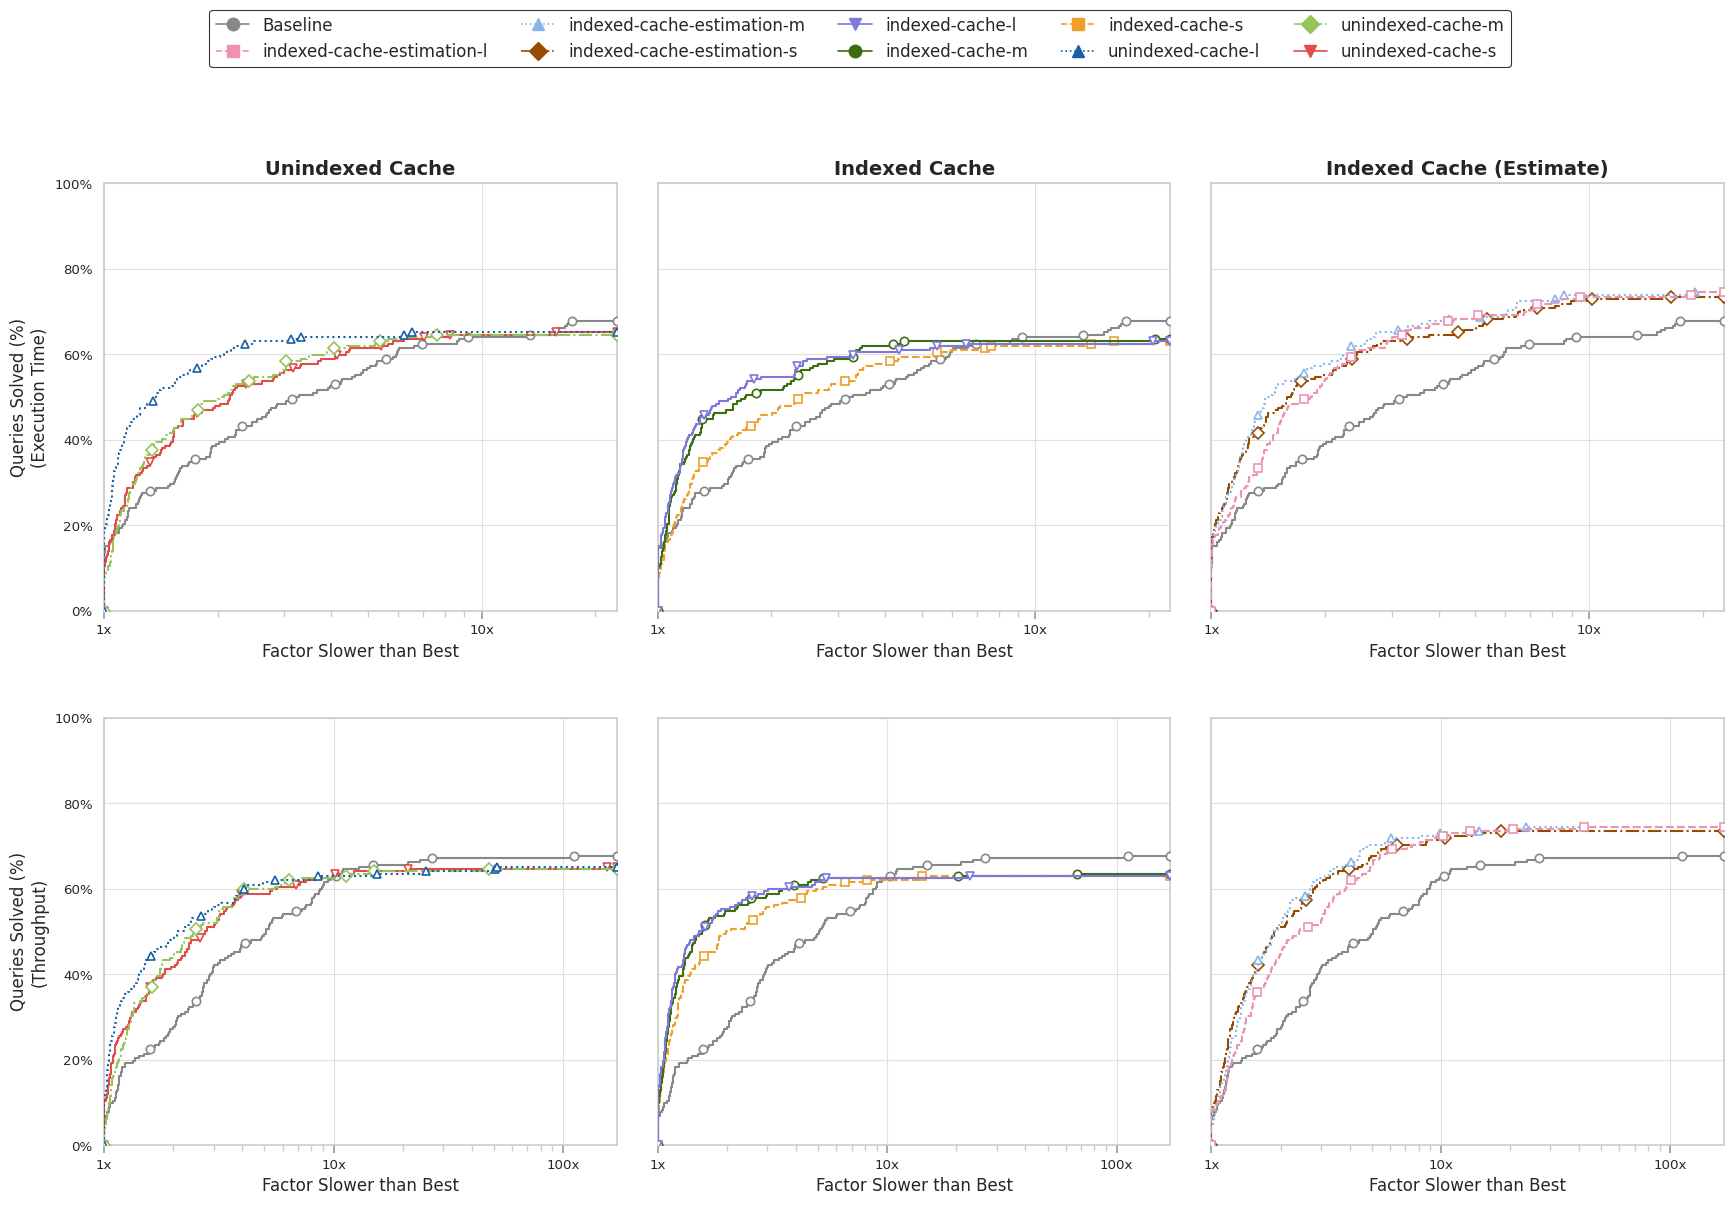

In [32]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

def get_algorithm_labels(locations):
    """
    Takes a list of file paths and returns a list of formatted algorithm labels.
    """
    def map_single(location_string):
        filename = os.path.basename(location_string).replace('.json', '')
        clean_name = filename.replace('query-results-raw-', '')

        if clean_name[-2:].lower() in ['-s', '-m', '-l']:
            size = clean_name[-1].lower()
            base_type = clean_name[:-2]
        else:
            return clean_name

        mapping = {
            'cache': 'unindexed-cache',
            'query-cache': 'indexed-cache',
            'query-cache-estimate': 'indexed-cache-estimation',
            'random-cache': 'unindexed-cache',
            'random-query-cache': 'indexed-cache',
            'random-query-cache-estimate': 'indexed-cache-estimation'

        }

        mapped_type = mapping.get(base_type, base_type)
        return f"{mapped_type}-{size}"

    return [map_single(loc) for loc in locations]


def plot_performance_profile(
    baseline_locations,
    cache_locations_1=None,
    cache_locations_2=None,
    cache_locations_3=None,
    metrics=['time'],
    algorithm_labels_1=None,
    algorithm_labels_2=None,
    algorithm_labels_3=None,
    facet_titles=["Unindexed Cache", "Indexed Cache", "Indexed Cache (Estimate)"],
    save_location=None
):
    """
    Plots a faceted Dolan-Moré Performance Profile.
    X-axis: Factor tau relative to the best performing algorithm.
    Y-axis: Fraction of queries solved within factor tau.
    """

    if isinstance(metrics, str):
        metrics = [metrics]

    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.1,
        rc={
            "axes.edgecolor": "#CCCCCC",
            "axes.linewidth": 1.2
        }
    )

    style_markers = ["o", "s", "^", "D", "v"]
    style_lines = ["-", "--", ":", "-.", "-"]

    def parse_group(filepaths, labels, default_label):
        records = []
        if not filepaths: return pd.DataFrame()
        for i, filepath in enumerate(filepaths):
            label = labels[i] if labels and i < len(labels) else f"{default_label}_{i}"
            if os.path.exists(filepath):
                with open(filepath, 'r') as f:
                    data = json.load(f)
                    if not isinstance(data, list): data = [data]

                    for item in data:
                        timestamps = item.get('timestamps', [])
                        first_ts = timestamps[0] if timestamps else None
                        last_ts = timestamps[-1] if timestamps else None
                        num_results = len(timestamps)

                        throughput = 0.0
                        if num_results > 0 and last_ts and last_ts > 0:
                            throughput = num_results / last_ts

                        records.append({
                            'name': item.get('name'),
                            'id': item.get('id'),
                            'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                            'algorithm': label,
                            'time': item.get('time'),
                            'first_ts': first_ts,
                            'last_ts': last_ts,
                            'num_results': num_results,
                            'throughput': throughput
                        })
        return pd.DataFrame(records)

    # 1. Load Data
    df_base = parse_group(baseline_locations, ["Baseline"] * len(baseline_locations), "Baseline")
    df_1 = parse_group(cache_locations_1, algorithm_labels_1, "Cache")
    df_2 = parse_group(cache_locations_2, algorithm_labels_2, "Query_Cache")
    df_3 = parse_group(cache_locations_3, algorithm_labels_3, "Estimate")

    df_all = pd.concat([df_base, df_1, df_2, df_3], ignore_index=True)

    if df_all.empty:
        print("DataFrame is empty. No plots to generate.")
        return

    # 2. Assign Global Colors
    algorithm_order = sorted(df_all['algorithm'].unique().tolist())
    if "Baseline" in algorithm_order:
        algorithm_order.insert(0, algorithm_order.pop(algorithm_order.index("Baseline")))

    # Load tab10 palette
    tab10 = sns.color_palette("tab10", 10)

    color_mapping = {
        'Baseline':                      '#888888',
        'unindexed-cache-s':             '#E24B4A',
        'indexed-cache-s':               '#EF9F27',
        'indexed-cache-estimation-s':    '#964B00',
        'unindexed-cache-m':             '#97C459',
        'indexed-cache-m':               '#3B6D11',
        'indexed-cache-estimation-m':    '#85B7EB',
        'unindexed-cache-l':             '#185FA5',
        'indexed-cache-l':               '#7F77DD',
        'indexed-cache-estimation-l':    '#ED93B1',
    }

    style_map = {}
    for i, alg in enumerate(algorithm_order):
        style_map[alg] = {
            'color': color_mapping.get(alg, tab10[i % 10]),
            'marker': style_markers[i % len(style_markers)],
            'ls': style_lines[i % len(style_lines)]
        }

    # 3. Aggregate identical runs and identify best performers
    df_agg = df_all.groupby(['name', 'id', 'template', 'algorithm']).agg({
        'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
        'num_results': 'median', 'throughput': 'median'
    }).reset_index()

    total_unique_queries = len(df_agg[['name', 'id', 'template']].drop_duplicates())
    df_success = df_agg[df_agg['num_results'] > 0]

    best_time = df_success.groupby(['name', 'id', 'template'])['time'].min().reset_index().rename(columns={'time': 'best_time'})
    best_tp = df_success.groupby(['name', 'id', 'template'])['throughput'].max().reset_index().rename(columns={'throughput': 'best_tp'})

    df_eval = pd.merge(df_agg, best_time, on=['name', 'id', 'template'], how='left')
    df_eval = pd.merge(df_eval, best_tp, on=['name', 'id', 'template'], how='left')

    # 4. Map Data to Facets
    facet_groups = [
        (facet_titles[0], pd.concat([df_base, df_1])['algorithm'].unique()),
        (facet_titles[1], pd.concat([df_base, df_2])['algorithm'].unique()),
        (facet_titles[2], pd.concat([df_base, df_3])['algorithm'].unique())
    ]
    facet_groups = [f for f in facet_groups if len(f[1]) > 1]
    num_facets = len(facet_groups)
    num_metrics = len(metrics)

    # 5. Initialize Plot Grid
    fig, axes = plt.subplots(num_metrics, num_facets,
                             figsize=(6.0 * num_facets, 6.5 * num_metrics),
                             squeeze=False, facecolor='white', sharex='row', sharey='row',
                             gridspec_kw={'wspace': 0.08, 'hspace': 0.25})

    # 6. Plotting Loop
    for row_idx, current_metric in enumerate(metrics):
        tau_col = f'tau_{current_metric}'
        df_eval[tau_col] = np.inf
        success_mask = df_eval['num_results'] > 0

        if current_metric in ['time', 'first_ts', 'last_ts']:
            valid_mask = success_mask & (df_eval['best_time'] > 0)
            df_eval.loc[valid_mask, tau_col] = df_eval.loc[valid_mask, 'time'] / df_eval.loc[valid_mask, 'best_time']
        elif current_metric == 'throughput':
            valid_mask = success_mask & (df_eval['throughput'] > 0)
            df_eval.loc[valid_mask, tau_col] = df_eval.loc[valid_mask, 'best_tp'] / df_eval.loc[valid_mask, 'throughput']

        row_max_tau = df_eval[tau_col].replace([np.inf, -np.inf], np.nan).max()
        if pd.isna(row_max_tau) or row_max_tau < 1.5:
            row_max_tau = 2.0
        else:
            row_max_tau = row_max_tau * 1.1

        for col_idx, (title, algs_in_facet) in enumerate(facet_groups):
            ax = axes[row_idx, col_idx]

            ax.grid(True, which='major', axis='both', color='#E0E0E0', linestyle='-', linewidth=0.8)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color('#CCCCCC')
                spine.set_linewidth(1.2)

            for alg in algs_in_facet:
                tau_vals = df_eval[df_eval['algorithm'] == alg][tau_col].values
                tau_vals = tau_vals[np.isfinite(tau_vals)]
                tau_vals.sort()

                if len(tau_vals) == 0: continue

                y_vals = np.arange(1, len(tau_vals) + 1) / total_unique_queries

                tau_plot = np.insert(tau_vals, 0, 1.0)
                y_plot = np.insert(y_vals, 0, 0.0)
                tau_plot = np.append(tau_plot, row_max_tau)
                y_plot = np.append(y_plot, y_plot[-1])

                if len(tau_plot) > 12:
                    log_taus = np.log10(tau_plot)
                    target_logs = np.linspace(log_taus.min(), log_taus.max(), 12)
                    m_every = sorted(list(set([np.argmin(np.abs(log_taus - t)) for t in target_logs])))
                else:
                    m_every = 1

                c_style = style_map[alg]

                ax.plot(
                    tau_plot, y_plot, drawstyle='steps-post', linewidth=1.5,
                    color=c_style['color'], linestyle=c_style['ls'],
                    marker=c_style['marker'], markevery=m_every,
                    markersize=6, markerfacecolor='white', markeredgewidth=1.2,
                    label=alg, zorder=3
                )

            # Locked Ax Formatting
            ax.set_xscale('log')
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}x'))
            ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

            ax.set_ylim(0, 1.0)
            ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.set_xlim(1.0, row_max_tau)

            # --- LOG SCALE MINOR TICKS FIX ---
            # Explicitly add log minor ticks and force them to render
            ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 1.0))
            ax.tick_params(axis='x', which='major', bottom=True, length=6, width=1.2, color='#999999', labelbottom=True)
            ax.tick_params(axis='x', which='minor', bottom=True, length=4, width=1.0, color='#CCCCCC')

            metric_title = "Throughput" if current_metric == 'throughput' else "Execution Time"

            # Force x-axis labels and tick names to appear on EVERY row
            ax.set_xlabel(f'Factor Slower than Best', fontsize=12)

            if row_idx == 0:
                ax.set_title(title, fontsize=14, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f'Queries Solved (%)\n({metric_title})', fontsize=12)
            else:
                ax.tick_params(axis='y', labelleft=False)

    # 7. Global Legend Construction
    custom_handles = []
    for alg in algorithm_order:
        c_style = style_map[alg]
        custom_handles.append(mlines.Line2D(
            [], [], color=c_style['color'], marker=c_style['marker'],
            linestyle=c_style['ls'],
            markersize=9,
            label=alg
        ))

    # Adjusted top margin to accommodate larger legend in the taller figure
    fig.subplots_adjust(top=0.82, bottom=0.08, left=0.08, right=0.98)

    # Legend sizing and positioning
    fig.legend(handles=custom_handles, labels=algorithm_order,
               loc='upper center', bbox_to_anchor=(0.5, 0.96),
               ncol=5,
               frameon=True,
               edgecolor='black',
               fontsize=12)

    if save_location:
        os.makedirs(os.path.dirname(save_location), exist_ok=True)
        # bbox_inches='tight' safely encompasses the legend and plots together
        plt.savefig(save_location, bbox_inches='tight', facecolor='white', transparent=False)
        print(f"Saved Performance Profile to: {save_location}")

    plt.show()

# Execution block remains the same
if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_locations_cache = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l ]
    all_locations_query_cache = [ raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l ]

    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    # Dynamically generate the algorithm labels based on filenames
    labels_cache = get_algorithm_labels(all_locations_cache)
    labels_query_cache = get_algorithm_labels(all_locations_query_cache)
    labels_estimate = get_algorithm_labels(all_locations_query_cache_estimate)

    plot_performance_profile(
        baseline_locations=location_default,
        cache_locations_1=all_locations_cache,
        cache_locations_2=all_locations_query_cache,
        cache_locations_3=all_locations_query_cache_estimate,
        algorithm_labels_1=labels_cache,
        algorithm_labels_2=labels_query_cache,
        algorithm_labels_3=labels_estimate,
        metrics=["time", "throughput"],
        save_location="../output/execution_time_figures/performance_profile.pdf"
    )

Saved Performance Profile to: ../output/execution_time_figures/performance_profile_random_sequences.pdf


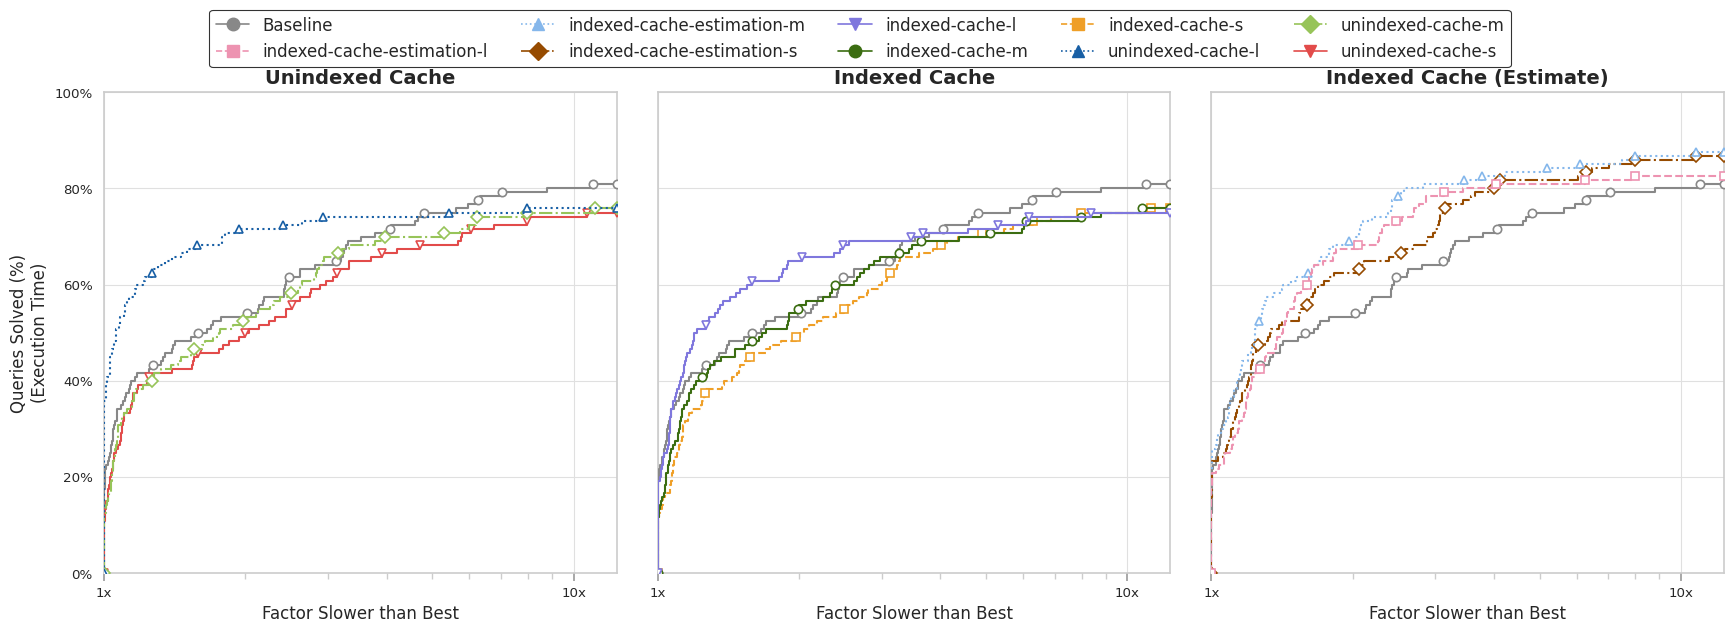

In [33]:
raw_data_cache_random_s = os.path.join("..", "data", "random_sequences", "query-results-raw-random-cache-s.json")
raw_data_cache_random_m = os.path.join("..", "data", "random_sequences", "query-results-raw-random-cache-m.json")
raw_data_cache_random_l = os.path.join("..", "data", "random_sequences", "query-results-raw-random-cache-l.json")

raw_data_query_cache_random_s = os.path.join("..", "data", "random_sequences", "query-results-raw-random-query-cache-s.json")
raw_data_query_cache_random_m = os.path.join("..", "data", "random_sequences", "query-results-raw-random-query-cache-m.json")
raw_data_query_cache_random_l = os.path.join("..", "data", "random_sequences", "query-results-raw-random-query-cache-l.json")

raw_data_query_cache_estimate_random_s = os.path.join("..", "data", "random_sequences",
                                                      "query-results-raw-random-query-cache-estimate-s.json")
raw_data_query_cache_estimate_random_m = os.path.join("..", "data", "random_sequences",
                                                      "query-results-raw-random-query-cache-estimate-m.json")
raw_data_query_cache_estimate_random_l = os.path.join("..", "data", "random_sequences",
                                                      "query-results-raw-random-query-cache-estimate-l.json")

all_locations_cache = [ raw_data_cache_random_s, raw_data_cache_random_m, raw_data_cache_random_l ]
all_locations_query_cache = [ raw_data_query_cache_random_s, raw_data_query_cache_random_m, raw_data_query_cache_random_l ]
all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_random_s,
                                       raw_data_query_cache_estimate_random_m,
                                       raw_data_query_cache_estimate_random_l ]
labels_cache = get_algorithm_labels(all_locations_cache)
labels_query_cache = get_algorithm_labels(all_locations_query_cache)
labels_estimate = get_algorithm_labels(all_locations_query_cache_estimate)

location_default = [ os.path.join("..", "data", "random_sequences", "query-results-raw-random-default.json") ]
plot_performance_profile(
    baseline_locations=location_default,
    cache_locations_1=all_locations_cache,
    cache_locations_2=all_locations_query_cache,
    cache_locations_3=all_locations_query_cache_estimate,
    algorithm_labels_1=labels_cache,
    algorithm_labels_2=labels_query_cache,
    algorithm_labels_3=labels_estimate,
    metrics=["time"],
    save_location="../output/execution_time_figures/performance_profile_random_sequences.pdf"
)
